In [24]:
!pip install -q ultralytics opencv-python-headless pillow matplotlib accelerate
!pip install -q git+https://github.com/huggingface/transformers

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [25]:
import os
import re
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

In [26]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [27]:
qwen_model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(qwen_model_id)

model_vl = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    qwen_model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

In [28]:
plate_model = YOLO("/content/best.pt")

In [80]:
image_path = "/content/WhatsApp Image 2026-04-02 at 11.45.52 AM.jpeg"

In [81]:
def show_img(img, title="image", figsize=(8,4), is_bgr=True):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        if is_bgr:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [82]:
def detect_plate_crop(image_path, plate_model):
    img = cv2.imread(image_path)
    results = plate_model(img)[0]

    if len(results.boxes) == 0:
        raise ValueError("No plate detected")

    best_box = max(results.boxes, key=lambda b: float(b.conf[0]))
    x1, y1, x2, y2 = map(int, best_box.xyxy[0].cpu().numpy())

    h, w = img.shape[:2]
    pad_x = int((x2 - x1) * 0.05)
    pad_y = int((y2 - y1) * 0.10)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)

    plate = img[y1:y2, x1:x2]
    return img, plate

In [83]:
def enhance_plate_for_qwen(plate_bgr, scale=3):
    # upscale
    up = cv2.resize(
        plate_bgr,
        None,
        fx=scale,
        fy=scale,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.cvtColor(up, cv2.COLOR_BGR2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # sharpen
    kernel = np.array([
        [0, -1,  0],
        [-1, 5, -1],
        [0, -1,  0]
    ])
    sharp = cv2.filter2D(gray, -1, kernel)

    return sharp


0: 960x736 1 license_plate, 57.5ms
Speed: 6.5ms preprocess, 57.5ms inference, 2.2ms postprocess per image at shape (1, 3, 960, 736)


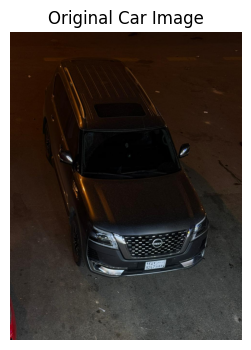

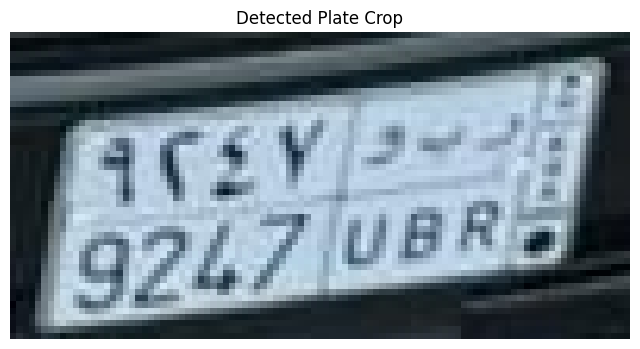

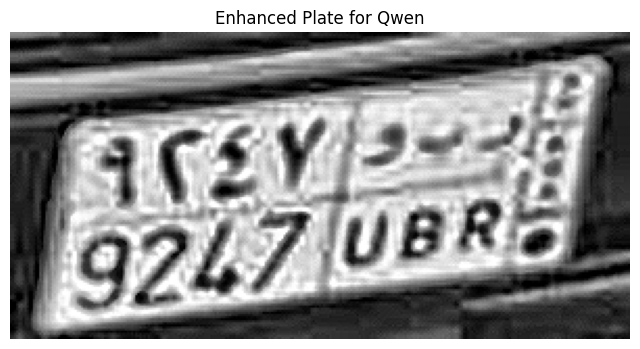

True

In [84]:
original_img, plate_crop = detect_plate_crop(image_path, plate_model)
enhanced_plate = enhance_plate_for_qwen(plate_crop, scale=3)

show_img(original_img, "Original Car Image")
show_img(plate_crop, "Detected Plate Crop")
show_img(enhanced_plate, "Enhanced Plate for Qwen", is_bgr=False)

enhanced_plate_path = "/content/enhanced_plate.png"
cv2.imwrite(enhanced_plate_path, enhanced_plate)

In [85]:
def read_plate_with_qwen(image_path, model_vl, processor):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": """
You are reading a Saudi vehicle license plate image.

Important:
- Read only the BOTTOM ENGLISH part of the Saudi plate.
- The bottom-left side contains exactly 4 English digits.
- The bottom-right side contains exactly 3 English letters.
- Ignore the Arabic text.
- Do not explain.
- Return only in this exact format:

DIGITS: XXXX
LETTERS: XXX
FINAL: XXXX XXX
"""
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs = [Image.open(image_path).convert("RGB")]

    inputs = processor(
        text=[text],
        images=image_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(model_vl.device) for k, v in inputs.items()}

    generated_ids = model_vl.generate(
        **inputs,
        max_new_tokens=128
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [86]:
qwen_output = read_plate_with_qwen(enhanced_plate_path, model_vl, processor)
print(qwen_output)

DIGITS: 9247
LETTERS: UBR
FINAL: 9247 UBR


In [87]:
def parse_plate_output(text):
    digits_match = re.search(r"DIGITS:\s*([A-Z0-9?]+)", text, re.IGNORECASE)
    letters_match = re.search(r"LETTERS:\s*([A-Z0-9?]+)", text, re.IGNORECASE)
    final_match = re.search(r"FINAL:\s*([A-Z0-9? ]+)", text, re.IGNORECASE)

    digits = digits_match.group(1).strip().upper() if digits_match else None
    letters = letters_match.group(1).strip().upper() if letters_match else None
    final = final_match.group(1).strip().upper() if final_match else None

    return digits, letters, final

In [88]:
digits, letters, final = parse_plate_output(qwen_output)

print("DIGITS:", digits)
print("LETTERS:", letters)
print("FINAL:", final)

DIGITS: 9247
LETTERS: UBR
FINAL: 9247 UBR
